# Reproducing C-TeC: Curiosity-Driven Exploration via Temporal Contrastive Learning

_**Paper:** Mohamed, Ji, Eysenbach & Berseth | RLBRew Workshop @ RLC 2025_

This notebook presents a from-scratch PyTorch reproduction of the C-TeC algorithm on MiniGrid 4-Rooms. C-TeC rewards an RL agent for visiting states whose futures appear improbable under learned temporal contrastive representations, driving exploration without any extrinsic reward.

I evaluate state coverage against a random baseline and RND, and investigate two design choices highlighted by the paper: **the temporal horizon (γ)** and the **future-state sampling strategy**.

![image.png](attachment:8d99e55a-ea5d-40d2-ade2-9672fc9d1050.png)

#### Equipement
This demo was run on a 24core CPU, RTX4090 24GB VRAM GPU

### Environment: MiniGrid 4-Rooms

The original paper evaluates C-TeC on high-dimensional locomotion (Ant, Humanoid mazes), manipulation (arm bin-pick), and Craftax environments. For this reproduction, I use MiniGrid 4-Rooms, a tabular-scale environment where state coverage can be measured exactly by counting visited grid cells. The 4-rooms layout creates narrow bottlenecks (single-cell doors) that make systematic exploration difficult: a random policy tends to stay trapped in one or two rooms. No extrinsic reward is used, only the C-TeC intrinsic reward drives the agent.

**Coverage metric:** The default grid is 19×19. After excluding outer walls and interior wall dividers, the environment contains **260 reachable cells** (empty floor + doors + goal).

**Episode length:** Each training episode runs for 3,000 environment steps. The paper uses 1,000 steps in its continuous-control environments (Table 1), where each step produces meaningful displacement. In MiniGrid's discrete action space, only **3 of 7 actions affect the agent's state** (left, right, forward), and only "forward" changes position. A 3,000-step budget gives the agent sufficient opportunity to traverse the grid while still making coverage a non-trivial challenge as a random policy covers only ~36% of the 260 reachable cells within this budget.

### Environment Description

![image](images/8d99e55a-ea5d-40d2-ade2-9672fc9d1050.png)


#### Action Space

| Num | Name | Action |
|-----|------|--------|
| 0 | left | Turn left |
| 1 | right | Turn right |
| 2 | forward | Move forward |
| 3 | pickup | Unused |
| 4 | drop | Unused |
| 5 | toggle | Unused |
| 6 | done | Unused |

We do NOT reduce the action space to 3 to keep the canonical environment for potential reproduction.

#### Observation Space

We use a compact 6-dimensional state vector rather than image observation. This keeps the focus on the exploration algorithm itself: a low-dimensional state is fast to iterate on and sufficient to demonstrate the core coverage behavior, while avoiding the confound of representation learning over pixel inputs.


| Num | State              | Value type      |
|-----|--------------------|-----------------|
| 0   | x-position on grid | int             |
| 1   | y-position on grid | int             |
| 2   | agent facing right | one-hot encoding |
| 3   | agent facing down  | one-hot encoding             |
| 4   | agent facing left  | one-hot encoding             |
| 5   | agent facing up    | one-hot encoding              |


We first visualize the environment with a short random rollout, then establish baseline performance.

The cell below will launch and run the environment for 20 steps, a good way to visualize it and test your installation.

In [35]:
%load_ext autoreload
%autoreload 2

import torch

from c_tec import get_config, make_env

STATE_DIM = 6
ACTION_DIM = 7
seed = 42
MAX_STEPS = 3000


env = make_env(seed=seed, max_steps=20, render_mode="human")
env.reset()
for _ in range(20):
        env.step(env.action_space.sample())

env.close()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Baseline: Random Policy

A uniform random policy serves as our lower bound. While a random walk on a finite 2D grid will eventually cover every reachable cell, convergence is slow especially through narrow doors. With 3,000 steps per episode, the random agent covers only ~36% of the grid, establishing the practical difficulty of the environment and motivating the need for directed exploration.


In [80]:
from c_tec.main import run_training, get_policy, run_evaluation
from c_tec.utils.visualization import plot_coverage_over_time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = make_env(seed=seed, max_steps=MAX_STEPS)
num_episodes = 50

random_policy = get_policy(state_dim=STATE_DIM, action_dim=ACTION_DIM, method="random", device=device)

random_logger, random_stats = run_evaluation(method="random", policy=random_policy, num_episodes=num_episodes, env=env, seed=seed, save=False)

random_trajectory_buffer = random_stats["trajectory_buffer"]

15:35:27 [INFO] evaluate: Running 50 evaluation episodes with random policy

Evaluating: 100%|██████████| 50/50 [00:10<00:00,  4.64it/s]
15:35:38 [INFO] evaluate: 
Evaluation complete: 50 episodes | Coverage: 38.4% ± 10.8% | Total steps: 150000


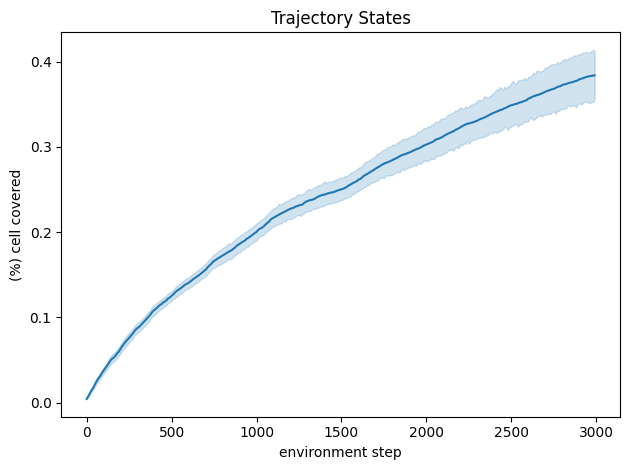

In [81]:
plot_coverage_over_time(trajectory_buffer=random_trajectory_buffer, save_path=None)

In [82]:
evaluation_env = make_env(seed=seed, max_steps=10000)

random_evaluation_logger, random_evaluation_stats = run_evaluation(method="random", policy=random_policy, num_episodes=num_episodes, env=evaluation_env, seed=seed, save=False)

random_evaluation_trajectory_buffer = random_evaluation_stats["trajectory_buffer"]

15:37:07 [INFO] evaluate: Running 50 evaluation episodes with random policy

Evaluating: 100%|██████████| 50/50 [00:35<00:00,  1.41it/s]
15:37:42 [INFO] evaluate: 
Evaluation complete: 50 episodes | Coverage: 68.5% ± 14.0% | Total steps: 500000


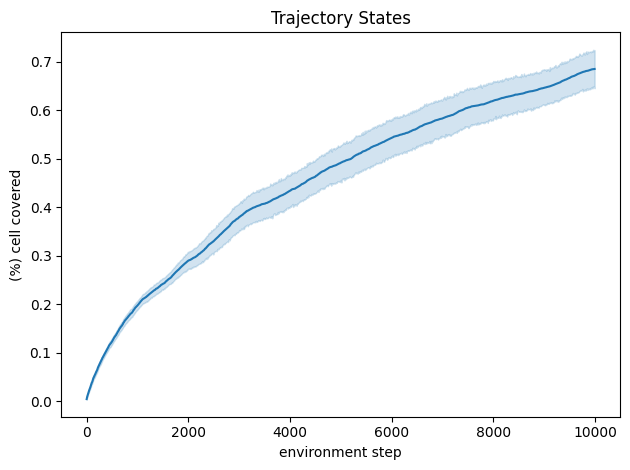

In [83]:
plot_coverage_over_time(trajectory_buffer=random_evaluation_trajectory_buffer, save_path=None)

After 10 000 steps, the random policy achieves ~70% state coverage

### Training C-TeC

We train C-TeC for 100 episodes (300K steps) with geometric future-state sampling (γ = 0.80). The contrastive critic uses L2 distance between normalized 32-dimensional representations, trained with InfoNCE loss. The policy is a PPO agent receiving only the intrinsic reward $r_{intr}(s_t, a_t) = \|\phi(s_t, a_t) - \psi(s_f)\|_2$ (Equation 5 of the paper).


Below, we visualize the grid cells coverage during training and how coverage compares to the random baseline.


In [59]:
C_TEC_CONFIG_PATH = "c-tec_config.yaml"
C_TEC_CONFIG = get_config(C_TEC_CONFIG_PATH)
c_tec_policy = get_policy(state_dim=STATE_DIM, action_dim=ACTION_DIM, method="c-tec", CONFIG=C_TEC_CONFIG, device=device)

c_tec_train_logger, c_tec_train_stats = run_training(method="c-tec", env=env, seed=seed, policy=c_tec_policy, num_episodes=C_TEC_CONFIG.env.num_episodes, save=False, log_interval=10)

c_tec_trajectory_buffer= c_tec_train_stats["trajectory_buffer"]

15:07:30 [INFO] train: Running 100 episodes with c-tec policy

Training:   9%|▉         | 9/100 [00:15<02:38,  1.74s/it]15:07:47 [INFO] train: mean reward: 0.3458 
15:07:47 [INFO] train: [Ep    10] Steps:    30000 | Avg coverage: 86.0 cells (33.1%) | Avg len: 3000 | Buffer: 10 traj | Loss 3.9836  π -0.0001  V 8.3563  H 1.9449
Training:  19%|█▉        | 19/100 [00:33<02:22,  1.76s/it]15:08:05 [INFO] train: mean reward: 0.1565 
15:08:05 [INFO] train: [Ep    20] Steps:    60000 | Avg coverage: 98.9 cells (38.0%) | Avg len: 3000 | Buffer: 20 traj | Loss 0.0873  π -0.0001  V 0.5631  H 1.9421
Training:  29%|██▉       | 29/100 [00:51<02:03,  1.74s/it]15:08:23 [INFO] train: mean reward: 0.1916 
15:08:23 [INFO] train: [Ep    30] Steps:    90000 | Avg coverage: 103.7 cells (39.9%) | Avg len: 3000 | Buffer: 30 traj | Loss -0.0399  π -0.0001  V 0.3074  H 1.9343
Training:  39%|███▉      | 39/100 [01:08<01:45,  1.73s/it]15:08:40 [INFO] train: mean reward: 0.1789 
15:08:40 [INFO] train: [Ep    40] St

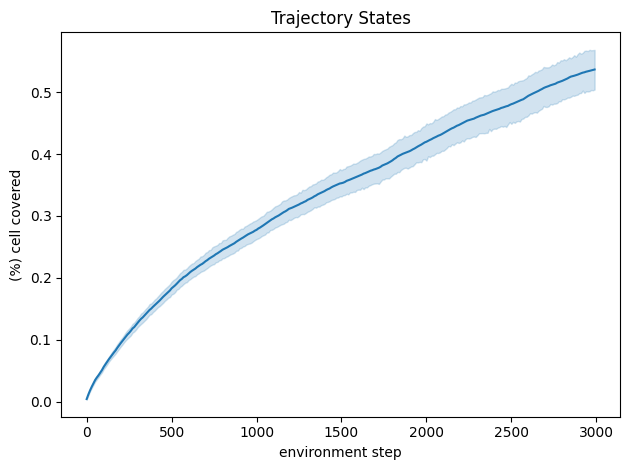

In [60]:
plot_coverage_over_time(trajectory_buffer=c_tec_trajectory_buffer, save_path=None)

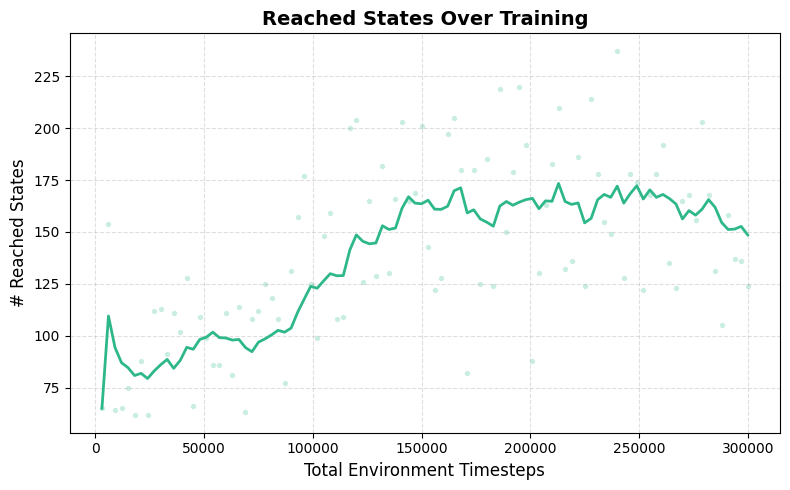

In [61]:
from c_tec.utils.visualization import plot_reached_states

plot_reached_states(train_logger=c_tec_train_logger, save_path=None)

15:11:08 [INFO] evaluate: Running 50 evaluation episodes with c-tec policy

Evaluating: 100%|██████████| 50/50 [03:36<00:00,  4.34s/it]
15:14:45 [INFO] evaluate: 
Evaluation complete: 50 episodes | Coverage: 94.8% ± 7.6% | Total steps: 500000


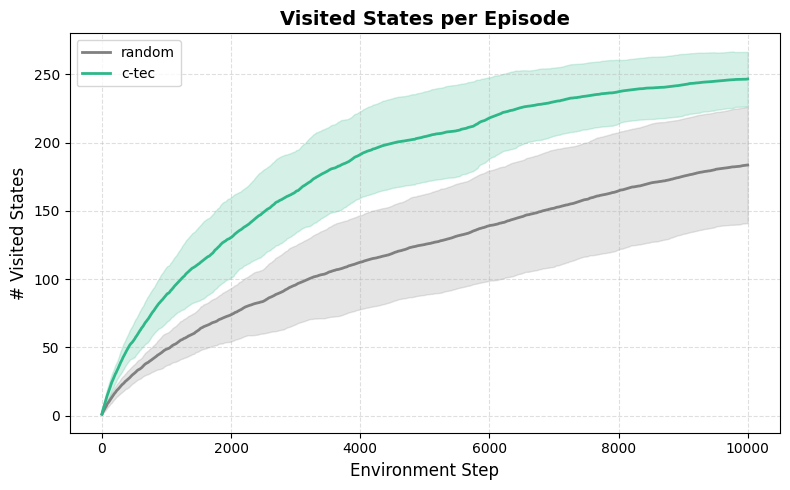

In [62]:
from c_tec.utils.visualization import plot_cumulative_coverage_comparison

c_tec_evaluation_logger, c_tec_evaluation_stats = run_evaluation(method="c-tec", policy=c_tec_policy, num_episodes=50, env=evaluation_env, seed=seed, save=False, from_checkpoint=False)

c_tec_evaluation_trajectory_buffer = c_tec_evaluation_stats["trajectory_buffer"]

buffers = {"random": random_trajectory_buffer, "c-tec": c_tec_evaluation_trajectory_buffer}

plot_cumulative_coverage_comparison(buffers)

After 10 000 steps, the c_tec policy achieves ~95% state coverage, clearly above the random baseline. The C-TeC intrinsic reward works to drive exploration

### Baseline: Random Network Distillation (RND)

RND (Burda et al., 2019) is a prediction-error baseline: a fixed random network maps states to embeddings, and a predictor network is trained to match these targets. Novel states, not yet seen during training, yield high prediction error, which serves as intrinsic reward. Unlike C-TeC, RND does not learn *temporal* representations: its novelty signal decays as the predictor fits the data, eventually approaching zero reward everywhere.

The paper highlights this vanishing-reward property as a key difference: C-TeC's reward does not tend to zero in the limit.


In [66]:
RND_CONFIG_PATH = "rnd_config.yaml"
RND_CONFIG = get_config(RND_CONFIG_PATH)

rnd_policy = get_policy(state_dim=STATE_DIM, action_dim=ACTION_DIM, method="rnd", CONFIG=RND_CONFIG, device=device)

rnd_train_logger, rnd_train_stats = run_training(method="rnd", env=env, seed=seed, policy=rnd_policy, num_episodes=RND_CONFIG.env.num_episodes, save=False, log_interval=10)

15:20:21 [INFO] train: Running 50 episodes with rnd policy

Training:  18%|█▊        | 9/50 [00:12<00:57,  1.41s/it]15:20:35 [INFO] train: mean reward (normalized): 3.6926 | RND predictor loss: 5.1048 | return running std: 1550.1885
15:20:35 [INFO] train: [Ep    10] Steps:    30000 | Avg coverage: 88.5 cells (34.0%) | Avg len: 3000 | Buffer: 10 traj | Loss 1881.8078  π 0.0002  V 3763.6348  H 1.9427
Training:  38%|███▊      | 19/50 [00:26<00:44,  1.45s/it]15:20:49 [INFO] train: mean reward (normalized): 2.4883 | RND predictor loss: 2.5969 | return running std: 1183.9655
15:20:49 [INFO] train: [Ep    20] Steps:    60000 | Avg coverage: 78.0 cells (30.0%) | Avg len: 3000 | Buffer: 20 traj | Loss 821.4070  π -0.0003  V 1642.8339  H 1.9310
Training:  58%|█████▊    | 29/50 [00:40<00:29,  1.40s/it]15:21:03 [INFO] train: mean reward (normalized): 1.5834 | RND predictor loss: 1.5147 | return running std: 999.1073
15:21:03 [INFO] train: [Ep    30] Steps:    90000 | Avg coverage: 93.5 cells (36.0

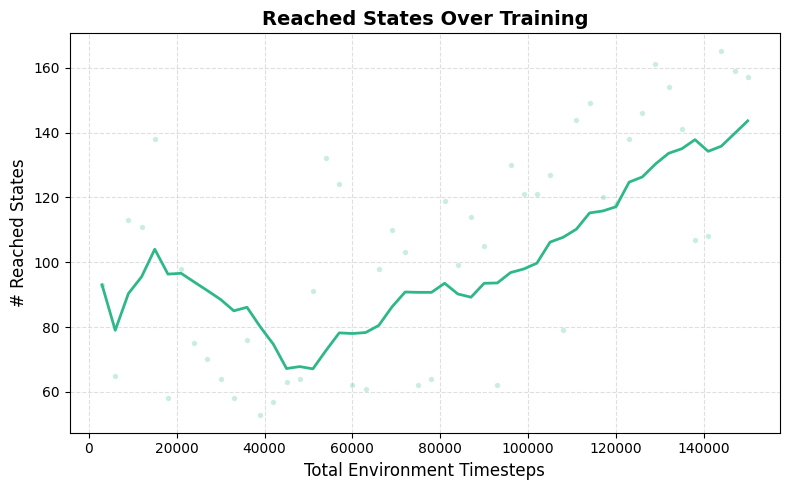

In [67]:
plot_reached_states(train_logger=rnd_train_logger, save_path=None)

We evaluate the rnd policy.

In [68]:
rnd_evaluation_logger, rnd_evaluation_stats = run_evaluation(method="rnd", policy=rnd_policy, num_episodes=50, env=evaluation_env, seed=seed, save=False, from_checkpoint=False)

rnd_evaluation_trajectory_buffer = rnd_evaluation_stats["trajectory_buffer"]

15:21:41 [INFO] evaluate: Running 50 evaluation episodes with rnd policy

Evaluating: 100%|██████████| 50/50 [03:38<00:00,  4.38s/it]
15:25:20 [INFO] evaluate: 
Evaluation complete: 50 episodes | Coverage: 87.3% ± 12.9% | Total steps: 500000


After 10 000 steps, the c_tec policy achieves ~85% state coverage, clearly above the random baseline but below what C-TeC achieves. It seems that, as the paper suggest, C-TeC is a clear improvement over existing methods.

We now compare all three methods side by side.

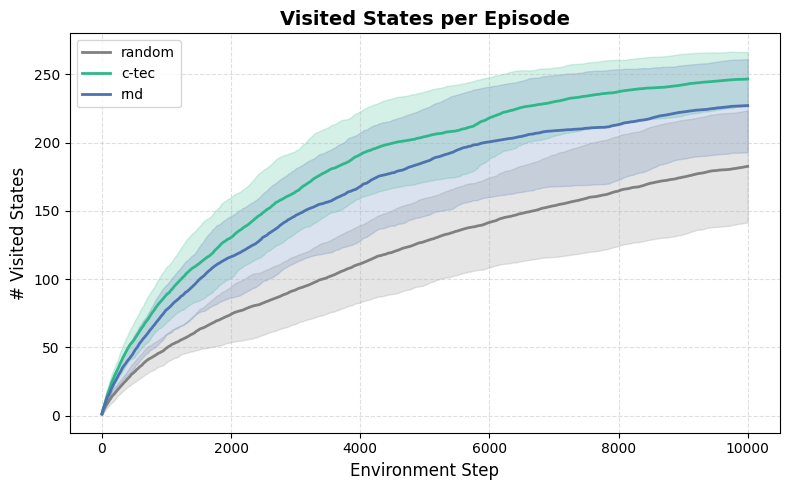

In [69]:
buffers = {"random": random_evaluation_trajectory_buffer, "c-tec": c_tec_evaluation_trajectory_buffer, "rnd": rnd_evaluation_trajectory_buffer}
plot_cumulative_coverage_comparison(buffers)

### Evaluation: State Coverage Heatmaps

To evaluate the exploration capabilities of C-TeC, we compare it against a baseline random exploration policy over 3000 thousand steps.

The heatmaps below visualize the **probability estimate of a specific cell being reached** during evaluation (averaged over 10 episodes). In a bottleneck environment like the 4-rooms grid, a naive policy will typically bounce around locally and fail to navigate through the narrow doors. We expect C-TeC's intrinsic reward to drive the agent through these bottlenecks to achieve uniform state coverage.

In [73]:
from c_tec.utils.visualization import plot_heatmap_of_position

import logging

logging.basicConfig(level=logging.DEBUG)

env = make_env(seed=seed, max_steps=3000)

random_evaluation_logger, random_evaluation_stats = run_evaluation(method="random", policy=random_policy, env=env,
                                                                   seed=seed, save=False, num_episodes=10,
                                                                   evaluate_multiple_seeds=False, from_checkpoint=False)

c_tec_evaluation_logger, c_tec_evaluation_stats = run_evaluation(method="c-tec", policy=c_tec_policy, env=env,
                                                                 seed=seed, save=False, num_episodes=10,
                                                                 evaluate_multiple_seeds=False, from_checkpoint=False)


15:27:05 [INFO] evaluate: Running 10 evaluation episodes with random policy

Evaluating: 100%|██████████| 10/10 [00:02<00:00,  4.60it/s]
15:27:07 [INFO] evaluate: 
Evaluation complete: 10 episodes | Coverage: 36.4% ± 8.8% | Total steps: 30000
15:27:07 [INFO] evaluate: Running 10 evaluation episodes with c-tec policy

Evaluating: 100%|██████████| 10/10 [00:13<00:00,  1.31s/it]
15:27:20 [INFO] evaluate: 
Evaluation complete: 10 episodes | Coverage: 57.2% ± 14.6% | Total steps: 30000


/var/home/lnoormam/Documents/C-TeC/c_tec/utils/visualization.py:118: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/home/lnoormam/Documents/C-TeC/c_tec/utils/visualization.py:118: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


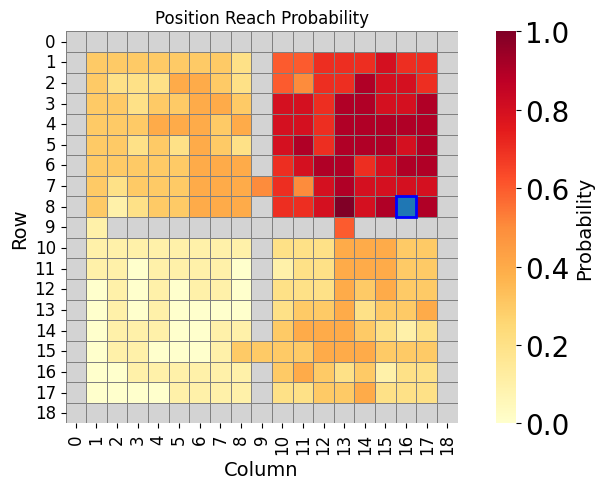

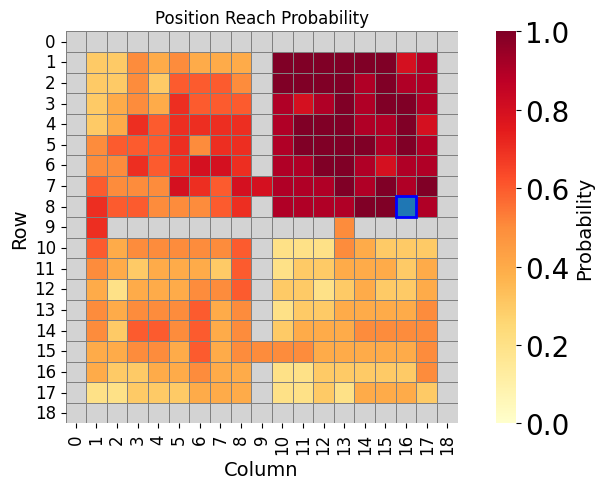

In [74]:
plot_heatmap_of_position(
            reached_count=random_evaluation_stats["reached_count"],
            n_episodes=10,
            reachable_cells=env.compute_reachable(),
            starting_cell=random_evaluation_stats["starting_pos"],
            save_path=None,
        )
plot_heatmap_of_position(
            reached_count=c_tec_evaluation_stats["reached_count"],
            n_episodes=10,
            reachable_cells=env.compute_reachable(),
            starting_cell=c_tec_evaluation_stats["starting_pos"],
            save_path=None,
        )

### Robust Exploration: Filtered Heatmaps (Probability > 20%)

To visualize the robust exploration paths more clearly, we filter out cells that have a reach probability of less than 20%.

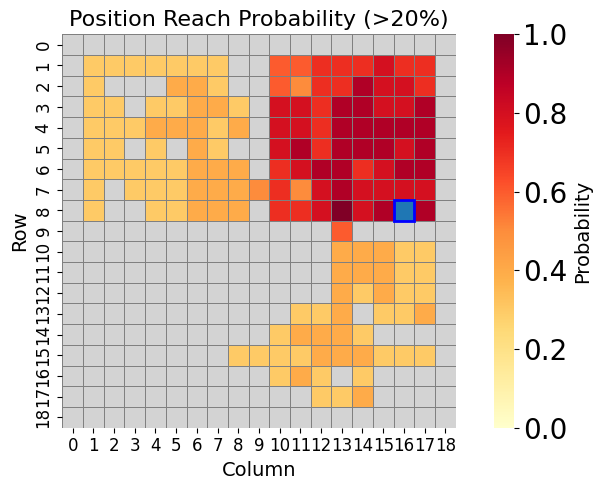

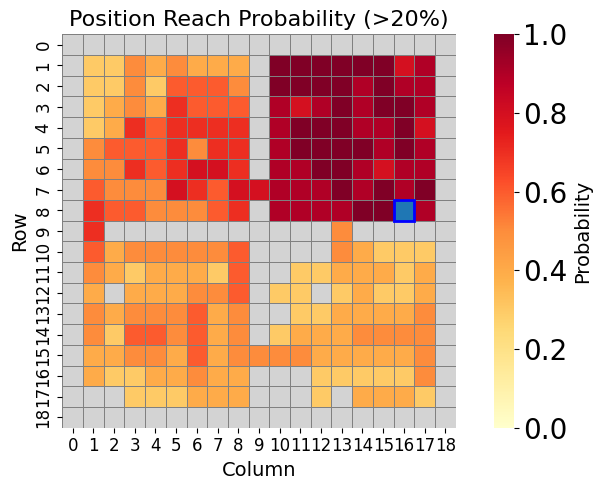

In [75]:
from c_tec.utils.visualization import plot_heatmap_of_position_filtered

plot_heatmap_of_position_filtered(
    reached_count=random_evaluation_stats["reached_count"],
    n_episodes=10,
    reachable_cells=env.compute_reachable(),
    starting_cell=random_evaluation_stats["starting_pos"],
    save_path=None,
    min_probability=0.2,
)

from c_tec.utils.visualization import plot_heatmap_of_position_filtered

plot_heatmap_of_position_filtered(
    reached_count=c_tec_evaluation_stats["reached_count"],
    n_episodes=10,
    reachable_cells=env.compute_reachable(),
    starting_cell=c_tec_evaluation_stats["starting_pos"],
    save_path=None,
    min_probability=0.2,)

Comparing C-TeC with the random policy under this threshold clearly highlights the difference in exploration efficiency. While the random agent struggles to reliably explore more than two rooms within the step limit, **C-TeC consistently manages to explore all four rooms**, demonstrating the effectiveness of temporal contrastive learning for intrinsic motivation.

### Ablation: Tuning the Temporal Horizon (γ) to Environment Scale

C-TeC samples future states via a geometric distribution Δ ~ GEOM(1−γ), with $E[Δ] = 1/(1−γ)$. The paper (Section 6.3) ablates γ-schedules but does not explicitly tune a fixed γ to match the spatial scale of a specific environment.

Here, I test the hypothesis that **the temporal horizon should reflect the characteristic length scale of the environment's bottlenecks.**

- With γ = 0.99 (long horizon), E[Δ] = 100 steps. In a small 4-rooms grid, 100 steps spans the entire maze; the future-state distribution becomes highly mixed and uninformative about local bottlenecks.
- With γ = 0.80 (short horizon), E[Δ] = 5 steps — roughly the radius of a single room. States near doors have 5-step futures that may cross into an unexplored room, yielding high intrinsic reward. States in room corners have predictable, local futures, yielding low reward.

By matching γ to the environment's spatial structure, we expect a sharper exploration signal concentrated at bottleneck transitions.


In [76]:
LONG_HORIZON_C_TEC_CONFIG_PATH = "demo/c-tec_long_horizon_config.yaml"
LONG_HORIZON_C_TEC_CONFIG = get_config(LONG_HORIZON_C_TEC_CONFIG_PATH)
high_gamma_c_tec_policy = get_policy(state_dim=STATE_DIM, action_dim=ACTION_DIM, method="c-tec", CONFIG=LONG_HORIZON_C_TEC_CONFIG, device=device)

long_horizon_c_tec_train_logger, long_horizon_c_tec_stats = run_training(method="c-tec", env=env, seed=seed, policy=high_gamma_c_tec_policy, num_episodes=LONG_HORIZON_C_TEC_CONFIG.env.num_episodes, save=False, log_interval=10)

15:28:28 [INFO] train: Running 100 episodes with c-tec policy

Training:   9%|▉         | 9/100 [00:16<02:40,  1.76s/it]15:28:46 [INFO] train: mean reward: 0.9086 
15:28:46 [INFO] train: [Ep    10] Steps:    30000 | Avg coverage: 97.5 cells (37.5%) | Avg len: 3000 | Buffer: 10 traj | Loss 11.6025  π 0.0000  V 23.5941  H 1.9454
Training:  19%|█▉        | 19/100 [00:33<02:23,  1.77s/it]15:29:03 [INFO] train: mean reward: 0.6449 
15:29:03 [INFO] train: [Ep    20] Steps:    60000 | Avg coverage: 118.9 cells (45.7%) | Avg len: 3000 | Buffer: 20 traj | Loss 5.5140  π -0.0000  V 11.4169  H 1.9448
Training:  29%|██▉       | 29/100 [00:51<02:05,  1.77s/it]15:29:21 [INFO] train: mean reward: 0.5658 
15:29:21 [INFO] train: [Ep    30] Steps:    90000 | Avg coverage: 101.1 cells (38.9%) | Avg len: 3000 | Buffer: 30 traj | Loss 4.1430  π 0.0000  V 8.6747  H 1.9439
Training:  39%|███▉      | 39/100 [01:09<01:46,  1.75s/it]15:29:39 [INFO] train: mean reward: 0.5531 
15:29:39 [INFO] train: [Ep    40] S

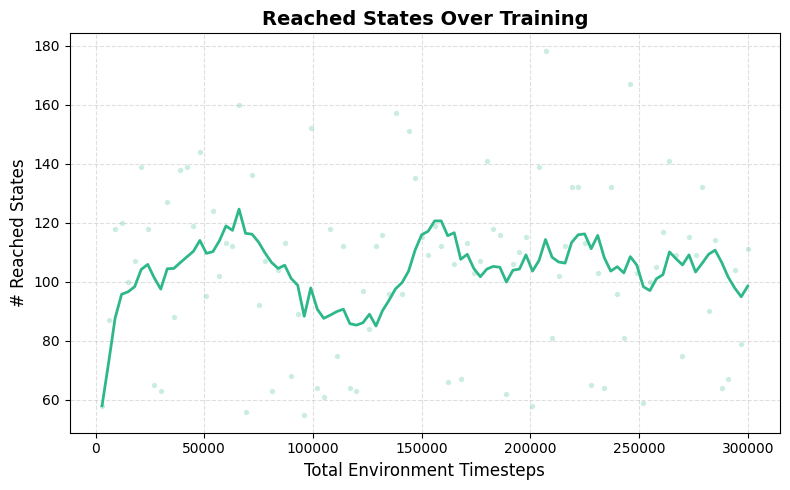

In [77]:
plot_reached_states(train_logger=long_horizon_c_tec_train_logger, save_path=None)

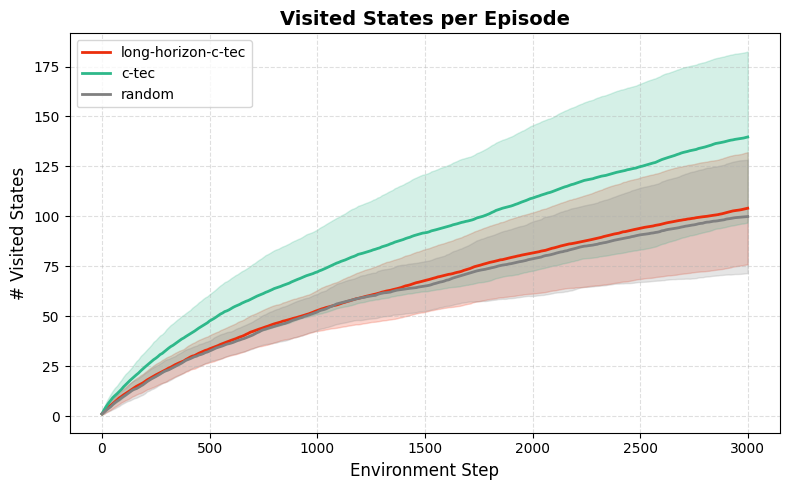

In [84]:
long_horizon_c_tec_trajectory_buffer = long_horizon_c_tec_stats["trajectory_buffer"]

buffers = {"long-horizon-c-tec": long_horizon_c_tec_trajectory_buffer, "c-tec": c_tec_trajectory_buffer, "random": random_trajectory_buffer}
plot_cumulative_coverage_comparison(buffers)

This ablation confirms a practical design insight: with γ = 0.80, C-TeC reaches \~60% coverage within 100 episodes, while γ = 0.99 plateaus around \~40% which is barely above the random baseline (~36%). The temporal horizon of the contrastive task must be matched to the spatial scale of the environment's bottlenecks for the intrinsic reward to provide a useful gradient.


Next, we test the second design choice: geometric vs. uniform future-state sampling.

### Ablation: Geometric vs. Uniform Future State Sampling

In Section 6.3 of the C-TeC paper, the authors investigate the algorithm's sensitivity to the future state sampling strategy. By default, C-TeC uses geometric sampling Δ ~ GEOM(1−γ), which exponentially decays the probability of sampling states further in the future.

An alternative is **uniform sampling**, which picks any future state in the remaining trajectory with equal probability. We test this to determine whether temporal locality is strictly necessary for effective exploration in a bottleneck environment.


In [87]:
UNIFORM_C_TEC_CONFIG_PATH = "demo/c-tec_uniform_config.yaml"
UNIFORM_C_TEC_CONFIG = get_config(UNIFORM_C_TEC_CONFIG_PATH)
uniform_c_tec_policy = get_policy(state_dim=STATE_DIM, action_dim=ACTION_DIM, method="c-tec", CONFIG=UNIFORM_C_TEC_CONFIG, device=device)

uniform_c_tec_train_logger,uniform_c_tec_stats  = run_training(method="c-tec", env=env, seed=seed, policy=uniform_c_tec_policy, num_episodes=UNIFORM_C_TEC_CONFIG.env.num_episodes, save=False, log_interval=10)

15:45:55 [INFO] train: Running 100 episodes with c-tec policy

Training:   9%|▉         | 9/100 [00:16<02:42,  1.79s/it]15:46:13 [INFO] train: mean reward: 1.1361 
15:46:13 [INFO] train: [Ep    10] Steps:    30000 | Avg coverage: 79.4 cells (30.5%) | Avg len: 3000 | Buffer: 10 traj | Loss 5.4694  π -0.0000  V 11.3280  H 1.9457
Training:  19%|█▉        | 19/100 [00:33<02:22,  1.76s/it]15:46:30 [INFO] train: mean reward: 0.4636 
15:46:30 [INFO] train: [Ep    20] Steps:    60000 | Avg coverage: 84.1 cells (32.3%) | Avg len: 3000 | Buffer: 20 traj | Loss 1.0296  π -0.0000  V 2.4483  H 1.9453
Training:  29%|██▉       | 29/100 [00:51<02:06,  1.78s/it]15:46:48 [INFO] train: mean reward: 0.7645 
15:46:48 [INFO] train: [Ep    30] Steps:    90000 | Avg coverage: 91.0 cells (35.0%) | Avg len: 3000 | Buffer: 30 traj | Loss 0.4442  π -0.0000  V 1.2772  H 1.9444
Training:  39%|███▉      | 39/100 [01:09<01:45,  1.73s/it]15:47:06 [INFO] train: mean reward: 0.4076 
15:47:06 [INFO] train: [Ep    40] Ste

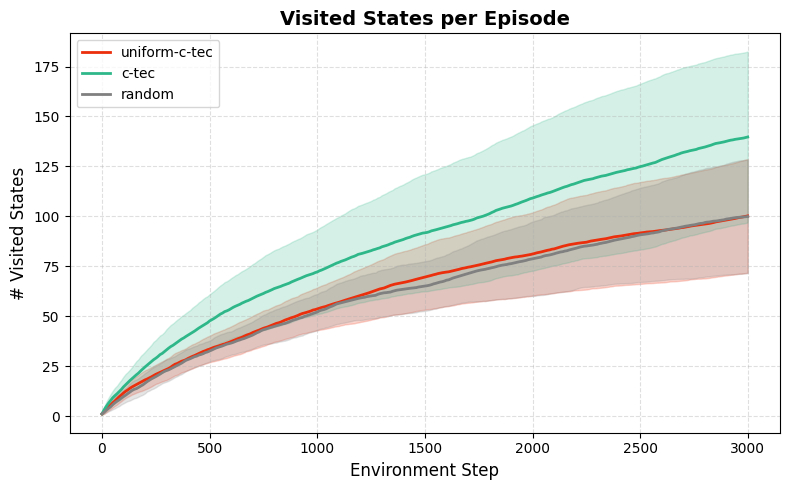

In [88]:
uniform_c_tec_trajectory_buffer=uniform_c_tec_stats["trajectory_buffer"]

buffers = {"uniform-c-tec": uniform_c_tec_trajectory_buffer, "c-tec": c_tec_trajectory_buffer, "random": random_trajectory_buffer}
plot_cumulative_coverage_comparison(buffers)

### Analysis: Uniform Sampling Fails in Bottleneck Environments

Empirically, **uniform sampling yields results no better than a random policy** in the 4-rooms environment.

**My hypothesis on why this happens:** The success of C-TeC relies on the contrastive model learning meaningful temporal distances. Geometric sampling enforces **temporal locality**, it trains the representations to capture local transitions. In the four rooms environment, this is where bottleneck structure lives: a single action near a door can drastically change the agent's immediate future.

Uniform sampling does not capture this locality. It forces the model to predict states far in the future with equal weight. In a small gridworld, an agent's position 100+ steps from now is largely independent of its current action it approaches the stationary distribution of a random walk.

When this happens, the conditional future distribution $p_T(s_f | s_t, a_t)$ becomes nearly indistinguishable from the marginal $p_T(s_f)$ (cf. Section 5.1, Equation 7 of the paper). The consequences cascade:

1. The InfoNCE loss cannot learn useful distinguishing features.
2. The representations φ and ψ collapse toward uniformity.
3. The intrinsic reward $\|\phi(s_t, a_t) - \psi(s_f)\|$ degrades into uninformative noise.

Without a structured intrinsic reward, the agent reverts to a random walk, remaining trapped in the starting rooms.


![image](images/5618c3d0-e225-4d3c-a70a-5e641f6552f7.png)

### Verification: RND's Vanishing Reward in Finite Environments

RND's intrinsic reward is the prediction error $\| f(s) - \hat{f}(s) \|^2$ between a fixed random target $f$ and a trained predictor $\hat{f}$. As training progresses, the predictor fits all previously visited states, driving the reward toward zero across the grid. In a finite environment like 4-rooms, this eventually flattens the reward landscape entirely, leaving the policy with no signal to prefer unexplored regions over familiar ones.

This is consistent with the C-TeC paper's observation (Section 6.2) that prediction-error methods "will eventually tend to zero reward as the state distribution is covered." C-TeC's temporal contrastive reward does not share this property the negated similarity $\|\phi(s_t, a_t) - \psi(s_f)\|$ maintains non-trivial values even after full coverage, which may explain the persistent advantage visible in the plot.


To verify this, we train an RND policy for longer (150 episodes instead of 50).

In [89]:
RND_LONG_TRAINING_CONFIG_PATH = "demo/rnd_long_training_config.yaml"
RND_LONG_TRAINING_CONFIG = get_config(RND_LONG_TRAINING_CONFIG_PATH)

rnd_long_training_policy = get_policy(state_dim=STATE_DIM, action_dim=ACTION_DIM, method="rnd", CONFIG=RND_LONG_TRAINING_CONFIG, device=device)

rnd_long_training_logger, rnd_long_training_stats = run_training(method="rnd", env=env, seed=seed, policy=rnd_policy, num_episodes=RND_LONG_TRAINING_CONFIG.env.num_episodes, save=False, log_interval=10)

15:50:26 [INFO] train: Running 150 episodes with rnd policy

Training:   6%|▌         | 9/150 [00:12<03:18,  1.41s/it]15:50:41 [INFO] train: mean reward (normalized): 4.9983 | RND predictor loss: 0.5571 | return running std: 10.5754
15:50:41 [INFO] train: [Ep    10] Steps:    30000 | Avg coverage: 149.7 cells (57.6%) | Avg len: 3000 | Buffer: 10 traj | Loss 2122.6691  π -0.0004  V 4245.3576  H 1.8582
Training:  13%|█▎        | 19/150 [00:26<03:05,  1.42s/it]15:50:55 [INFO] train: mean reward (normalized): 4.9983 | RND predictor loss: 0.4565 | return running std: 10.1198
15:50:55 [INFO] train: [Ep    20] Steps:    60000 | Avg coverage: 163.7 cells (63.0%) | Avg len: 3000 | Buffer: 20 traj | Loss 2063.0475  π -0.0011  V 4126.1147  H 1.7548
Training:  19%|█▉        | 29/150 [00:40<02:48,  1.39s/it]15:51:09 [INFO] train: mean reward (normalized): 4.9983 | RND predictor loss: 0.3499 | return running std: 10.3170
15:51:09 [INFO] train: [Ep    30] Steps:    90000 | Avg coverage: 165.1 cells (

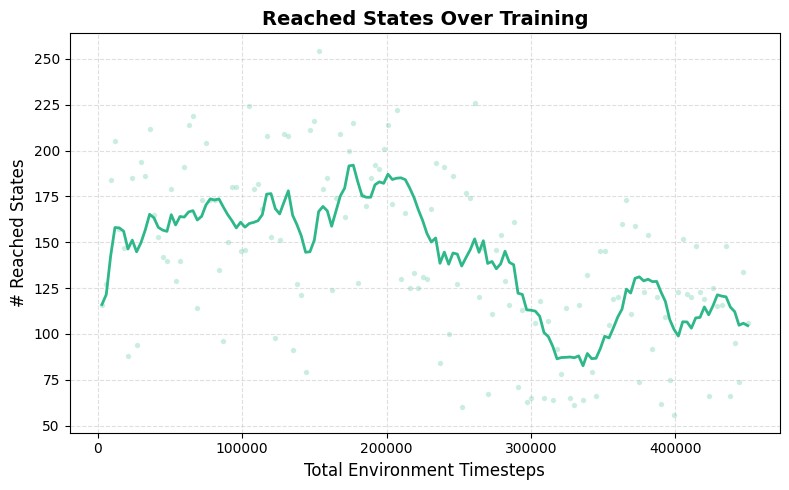

In [90]:
plot_reached_states(train_logger=rnd_long_training_logger, save_path=None)

In [91]:
rnd_long_training_eval_logger, rnd_long_training_eval_stats= run_evaluation(method="rnd", policy=rnd_long_training_policy, num_episodes=50, env=evaluation_env, seed=seed, save=False, from_checkpoint=False,)

15:54:12 [INFO] evaluate: Running 50 evaluation episodes with rnd policy

Evaluating: 100%|██████████| 50/50 [03:39<00:00,  4.40s/it]
15:57:52 [INFO] evaluate: 
Evaluation complete: 50 episodes | Coverage: 67.4% ± 15.7% | Total steps: 500000


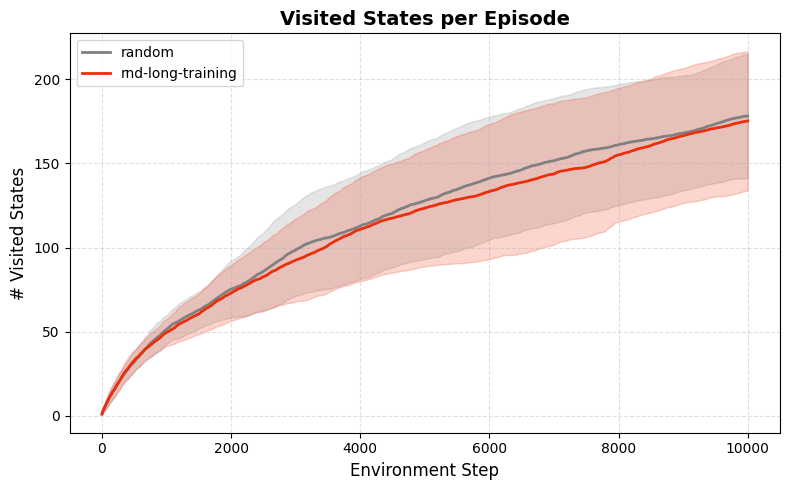

In [93]:
buffers = {"random": random_evaluation_trajectory_buffer,  "rnd-long-training": rnd_long_training_eval_stats["trajectory_buffer"], }
plot_cumulative_coverage_comparison(buffers)

As expected, an **overtrained** RND policy were the flattening of reward led to a forgetting of the exploration capabilities, performs no better than the random policy.

### Observation: Reward Instability under Non-Stationary Representations

The contrastive model successfully learns temporal structure from the buffer: the spatial clustering visible in the reward heatmaps confirms that nearby cells receive similar rewards, that doors and room boundaries produce meaningful reward gradients, and that the model faithfully tracks the buffer's density ratio at each update.


![image](images/443c0a26-54ff-4fc4-a3f3-1507a3183af2.png)
![image](images/4c42b739-0cef-45ae-99bd-2093041e94dd.png)
![image](images/e4ed3ffd-36e1-405b-b8b4-7a489868c58e.png)
![image](images/cc19d29a-a033-4860-8060-d403c6b06803.png)

However, the reward map does not expand smoothly outward from the start cell as observed in the original paper (Figure 3). Instead, the high-reward region jumps from a distance region to a region close the starting region in an oscillating pattern causing the policy to chase a moving target and never commit to a consistent exploration direction.

My hypothesis is that each new batch of trajectories causes a local shift in the buffer distribution $p_{T}(s_f)$, which the contrastive model correctly captures but because the encoders $\phi$ and $\psi$ share parameters across all states, retraining on the updated buffer rearranges embeddings globally, turning a small local distributional change into a global change of the reward landscape.

In [ ]:
reward_policy = get_policy(method="c-tec", CONFIG=C_TEC_CONFIG, device=device, state_dim=STATE_DIM, action_dim=ACTION_DIM)

run_training(
            method="c-tec",
            policy=reward_policy,
            env=env,
            seed=seed,
            num_episodes=C_TEC_CONFIG.env.num_episodes,
            save=False,
            log_interval=10,
            use_multiple_seeds=False,
            plot_rewards_interval=10,
        )